In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import kmeans_plusplus
import pickle

In [2]:
# ------------------------------------------------
# 1. Dataset configuration
# ------------------------------------------------
# NOTE: Update feature_cols per dataset to match your CSV schema.

DATASET_CONFIG = {
    "adult": {
        "csv_path": "data/adult_preprocessed.csv",
        "feature_cols": [
            "age", "final-weight", "education-num", "marital-status",
            "occupation", "relationship", "capital-gain",
            "hours-per-week", "native-country", "income"
        ],
        "sensitive_col": "sex",
        "k": 7,
        "tag": "adult",   # used in file names
    },
    
    "student": {
        "csv_path": "data/student_preprocessed.csv",         # <-- FILL THIS
        "feature_cols": [
            'school', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
           'Mjob', 'Fjob', 'traveltime', 'studytime', 'failures', 'schoolsup',
           'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet',
           'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
           'absences'
        ],
        "sensitive_col": "sex",                    # <-- Example
        "k": 5,
        "tag": "student"
    },
    "bank": {
        "csv_path": "data/bank_preprocessed.csv",
        "feature_cols": [
            'age', 'balance', 'duration'
        ],
        "sensitive_col": "marital",         # <-- Example
        "k": 5,
        "tag": "bank"
    },
    "credit": {
        "csv_path": "data/credit_preprocessed.csv",     # <-- FILL THIS
        "feature_cols": [
            'LIMIT_BAL', 'SEX', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
            'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
        ],
        "sensitive_col": "MARRIAGE",                    # <-- Example, change if needed
        "k": 5,
        "tag": "credit"
    }
}


In [3]:
# ------------------------------------------------
# 2. Utility functions
# ------------------------------------------------

def load_dataset(dataset_name: str):
    """Load dataset, standardize features, and build XA / XB."""
    cfg = DATASET_CONFIG[dataset_name]
    df = pd.read_csv(cfg["csv_path"])

    X = df[cfg["feature_cols"]].values
    s = df[cfg["sensitive_col"]].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    unique_vals = np.unique(s[~pd.isna(s)])

    print(f"Sensitive column '{cfg['sensitive_col']}' unique values:", unique_vals)

    if len(unique_vals) != 2:
        raise ValueError(
            f"Sensitive attribute must be binary. Found {len(unique_vals)} values."
        )

    val_A, val_B = unique_vals

    A_mask = (s == val_A)
    B_mask = (s == val_B)

    XA = X_scaled[A_mask]
    XB = X_scaled[B_mask]

    print(f"Dataset '{dataset_name}': {len(XA)} in group A ({val_A}), "
        f"{len(XB)} in group B ({val_B})")
    
    print(f"[{dataset_name}] n = {len(X_scaled)}")
    print(f"[{dataset_name}] |A| = {A_mask.sum()}, |B| = {B_mask.sum()}")
    assert A_mask.sum() + B_mask.sum() == len(X_scaled)
     

    return X_scaled, XA, XB, cfg

def _group_masks_from_sets(X, XA, XB):
    """
    Given full dataset X and subsets XA, XB, 
    return boolean masks inA, inB such that:
    inA[i] = True if X[i] ∈ XA
    inB[i] = True if X[i] ∈ XB
    """
    Xv  = np.ascontiguousarray(X).view([('', X.dtype)] * X.shape[1]).ravel()
    XAv = np.ascontiguousarray(XA).view([('', XA.dtype)] * XA.shape[1]).ravel()
    XBv = np.ascontiguousarray(XB).view([('', XB.dtype)] * XB.shape[1]).ravel()
    inA = np.in1d(Xv, XAv)
    inB = np.in1d(Xv, XBv)
    return inA, inB


def _assign(X, C):
    """
    Assign each data point in X to its closest cluster center in C.
    Returns:
        a   : array of cluster indices for each point
        d2  : squared distances to all centers
    """
    d2 = np.sum((X[:, None, :] - C[None, :, :]) ** 2, axis=2)
    return np.argmin(d2, axis=1), d2


def _kmeans_grad(X, C, a):
    """
    Gradient of the standard k-means objective:
      1/N Σ ||x - μ_c||²
    Returns:
        grad, counts, means
    """
    K, D = C.shape
    N = len(X)
    sums = np.zeros_like(C)
    np.add.at(sums, a, X)
    counts = np.bincount(a, minlength=K).astype(np.float64).reshape(-1, 1)
    means = np.divide(sums, np.maximum(counts, 1.0), where=counts > 0)
    grad = 2.0 * counts * (C - means) / N
    return grad, counts, means


def _group_kmeans_grad(X, C, a, group_mask):
    """
    Group-wise k-means gradient:
      1/|G| Σ_{i∈G} ||x - μ_c||²
    for a given group G.
    Returns:
        grad, group_loss
    """
    Xg = X[group_mask]
    ag = a[group_mask]
    if len(Xg) == 0:
        return np.zeros_like(C), 0.0

    K, D = C.shape
    G = len(Xg)
    sums = np.zeros_like(C)
    np.add.at(sums, ag, Xg)
    counts = np.bincount(ag, minlength=K).astype(np.float64).reshape(-1, 1)
    means = np.divide(sums, np.maximum(counts, 1.0), where=counts > 0)
    grad = 2.0 * counts * (C - means) / G
    loss = np.sum((Xg - C[ag]) ** 2) / G
    return grad, loss


def _separation_grad_for_group(Gpts, C, eps=1e-12):
    """
    Separation gradient for one group:
      1/|G| Σ s(x)^2,
    where s(x) is the signed distance to the nearest Voronoi bisector
    between the two closest centroids.
    Returns:
        grad, separation_value
    """
    if len(Gpts) == 0:
        return np.zeros_like(C), 0.0

    # Distances to all centers
    d2 = np.sum((Gpts[:, None, :] - C[None, :, :]) ** 2, axis=2)
    m1_idx = np.argmin(d2, axis=1)
    d2_mask = d2.copy()
    d2_mask[np.arange(len(Gpts)), m1_idx] = np.inf
    m2_idx = np.argmin(d2_mask, axis=1)

    m1, m2 = C[m1_idx], C[m2_idx]
    m = 0.5 * (m1 + m2)
    v = m2 - m1
    vn = np.linalg.norm(v, axis=1, keepdims=True)
    vhat = v / np.maximum(vn, eps)

    s = np.sum((Gpts - m) * vhat, axis=1)
    Px = (Gpts - m) - vhat * s[:, None]

    grad_m1 = (2.0 * s)[:, None] * (-(Px / np.maximum(vn, eps)) - 0.5 * vhat)
    grad_m2 = (2.0 * s)[:, None] * ((Px / np.maximum(vn, eps)) - 0.5 * vhat)

    K, D = C.shape
    grad = np.zeros_like(C)
    np.add.at(grad, m1_idx, grad_m1)
    np.add.at(grad, m2_idx, grad_m2)
    grad /= len(Gpts)

    val = np.mean(s ** 2)
    return grad, val

def compute_weights(lam, mode):

    if mode == "balanced":
        alpha = lam / 2.0
        beta = lam / 2.0

    elif mode == "social_heavy":
        alpha = 0.75 * lam
        beta = 0.25 * lam

    elif mode == "separation_heavy":
        alpha = 0.25 * lam
        beta = 0.75 * lam

    else:
        raise ValueError("Unknown weighting mode")

    return alpha, beta

In [4]:
def save_experiment_data(all_histories, dataset_name, tag):
    save_path = Path(f"raw_data_{dataset_name}_{tag}.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(all_histories, f)
    print(f"Full trajectory data saved to {save_path}")

def load_experiment_data(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f)

In [5]:
# ------------------------------------------------
# 3. Training combined (social + separation) k-means
# ------------------------------------------------

def train_combined_kmeans(
    X, XA, XB, k,
    alpha=0.5, beta=0.5,
    seeds=range(10), iters=500, lr=0.5,
    verbose=False,
):
    inA, inB = _group_masks_from_sets(X, XA, XB)
    N, D = X.shape
    history = []

    for seed in seeds:
        initial_centroids, _ = kmeans_plusplus(X, n_clusters=k, random_state=seed)
        C = initial_centroids.copy()
        full_traj = []
        # --- PHASE 1: Initial Lloyd's (Warm-up) ---
        for t_lloyd in range(100):
            a, _ = _assign(X, C)
            km_val = np.mean(np.sum((X - C[a]) ** 2, axis=1))
            
            # During Lloyd's, social/sep are 0 in the objective, but we log raw values
            _, LA = _group_kmeans_grad(X, C, a, inA)
            _, LB = _group_kmeans_grad(X, C, a, inB)
            _, cfdA = _separation_grad_for_group(X[inA], C)
            _, cfdB = _separation_grad_for_group(X[inB], C)
            
            l_max, s_min = max(LA, LB), min(cfdA, cfdB)
            
            full_traj.append({
                "phase": "lloyd", "iter": t_lloyd,
                "kmeans": km_val, "social_raw": l_max, "sep_raw": s_min,
                "social_w": 0.0, "sep_w": 0.0, # Not part of objective yet
                "total": km_val
            })

            sums = np.zeros_like(C); np.add.at(sums, a, X)
            counts = np.bincount(a, minlength=k).astype(float).reshape(-1, 1)
            new_centroids = np.divide(sums, np.maximum(counts, 1.0), where=counts > 0)
            
            if np.allclose(new_centroids, C, atol=1e-7):
                C = new_centroids
                break
            C = new_centroids

        # --- PHASE 2: Gradient Descent (Fairness Optimization) ---
        if alpha > 0 or beta > 0:
            start_t = len(full_traj)
            for t_grad in range(iters):
                a, _ = _assign(X, C)
                
                # Gradients and Values
                g_km, _, _ = _kmeans_grad(X, C, a)
                km_val = np.mean(np.sum((X - C[a]) ** 2, axis=1))

                gA, LA = _group_kmeans_grad(X, C, a, inA)
                gB, LB = _group_kmeans_grad(X, C, a, inB)
                g_social, l_max = (gA, LA) if LA >= LB else (gB, LB)

                g_sep_A, cfdA = _separation_grad_for_group(X[inA], C)
                g_sep_B, cfdB = _separation_grad_for_group(X[inB], C)
                g_sep, s_min = (g_sep_A, cfdA) if cfdA <= cfdB else (g_sep_B, cfdB)

                # Gradient Update
                C -= lr * (g_km + alpha * g_social - beta * g_sep)

                w_soc, w_sep = alpha * l_max, beta * s_min
                total_obj = km_val + w_soc - w_sep

                full_traj.append({
                    "phase": "grad", "iter": start_t + t_grad,
                    "kmeans": km_val, "social_raw": l_max, "sep_raw": s_min,
                    "social_w": w_soc, "sep_w": w_sep,
                    "total": total_obj
                })
                if verbose and seed == 0 and (t_grad % 50 == 0 or t_grad == iters - 1):
                    print(f"[Iter {t_grad:03d}] KM: {km_val:.4f} | Soc_raw: {l_max:.4f} | Sep_raw: {s_min:.4f}")
        # Final Evaluation
        a, _ = _assign(X, C)
        _, LA = _group_kmeans_grad(X, C, a, inA)
        _, LB = _group_kmeans_grad(X, C, a, inB)
        _, cfdA = _separation_grad_for_group(X[inA], C)
        _, cfdB = _separation_grad_for_group(X[inB], C)
        
        history.append({
            "seed": seed, "centers": C.copy(), "trajectory": full_traj,
            "final_metrics": {
                "kmeans": np.mean(np.sum((X - C[a]) ** 2, axis=1)),
                "social_max": max(LA, LB), "sep_min": min(cfdA, cfdB),
                "obj": km_val + alpha*max(LA, LB) - beta*min(cfdA, cfdB)
            }
        })
    return history

In [ ]:
def plot_loss_curves_per_lambda(all_histories, lambda_list, tag, save_dir="./plots"):
    n_lam = len(lambda_list)
    fig, axes = plt.subplots(1, n_lam, figsize=(5 * n_lam, 5), sharey=True)
    if n_lam == 1: axes = [axes]

    for i, lam in enumerate(lambda_list):
        ax = axes[i]
        histories = all_histories.get(lam, [])
        if not histories: continue

        max_len = max(len(h["trajectory"]) for h in histories)
        km_all, soc_all, sep_all = [], [], []

        for h in histories:
            traj = h["trajectory"]
            pad_size = max_len - len(traj)
            traj_data = traj + [traj[-1]] * pad_size 
            
            km_all.append([p["kmeans"] for p in traj_data])
            soc_all.append([p["social_raw"] for p in traj_data])
            sep_all.append([p["sep_raw"] for p in traj_data])

        x = np.arange(max_len)
        
        def plot_with_shade(ax, x, data_matrix, label, color):
            mean = np.mean(data_matrix, axis=0)
            std = np.std(data_matrix, axis=0)
            ax.plot(x, mean, label=label, color=color, linewidth=2)
            ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.1)

        plot_with_shade(ax, x, km_all, r"$k$-means Loss", "C1")
        plot_with_shade(ax, x, soc_all, r"Social Loss", "C3")
        plot_with_shade(ax, x, sep_all, r"Separation Loss", "C2")

        ax.set_title(rf"$\lambda = {lam}$", fontsize=14)
        ax.set_xlabel("Iterations", fontsize=14)
        ax.tick_params(axis='both', labelsize=13)
        ax.grid(True, linestyle='--', alpha=0.5)

    axes[0].set_ylabel("Loss", fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=14)
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    # --- SAVE LOGIC ---
    from pathlib import Path
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True) # Create folder if it doesn't exist
    
    file_name = save_path / f"loss_curves_{tag}.pdf"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {file_name}")
    # ------------------

    plt.show()

In [7]:
def run_separation_social_pipeline(
    dataset_name: str,
    lambda_list=None,
    seeds=range(10),
    iters=500,
    lr=0.5,
    save_dir="./plots",
    weight_mode="balanced"
):
    if lambda_list is None:
        lambda_list = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

    X_input, XA, XB, cfg = load_dataset(dataset_name)
    k = cfg["k"]
    tag = cfg["tag"]

    rows = []
    all_histories = {} 
    
    for lam in lambda_list:
        print(f"\n=== {dataset_name} | λ = {lam} ===")
        alpha, beta = compute_weights(lam, weight_mode)
        
    
        hist = train_combined_kmeans(
            X_input, XA, XB, k,
            alpha=alpha, beta=beta,
            seeds=seeds, iters=iters, lr=lr,
            verbose=False,
        )
        all_histories[lam] = hist

       
        def agg(key):
            vals = np.asarray([d["final_metrics"].get(key, 0) for d in hist], float)
            return vals.mean(), vals.std()
        
        
        km_m, km_s           = agg("kmeans")
        soc_m, soc_s         = agg("social_max")
        sep_m, sep_s         = agg("sep_min")    
        obj_m, obj_s         = agg("obj")       
        
        sg_m, sg_s           = agg("social_gap") 
        sep_gap_m, sep_gap_s = agg("separation_gap")

        rows.append({
            "lambda": lam,
            "kmeans_mean": km_m,        "kmeans_std": km_s,
            "social_mean": soc_m,       "social_std": soc_s,
            "separation_mean": sep_m,   "separation_std": sep_s,
            "objective_mean": obj_m,    "objective_std": obj_s,
            "social_gap_mean": sg_m,    "social_gap_std": sg_s,
            "sep_gap_mean": sep_gap_m,  "sep_gap_std": sep_gap_s,
        })

  
    df_lam = pd.DataFrame(rows).sort_values("lambda").reset_index(drop=True)
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    
  
    out_csv = Path(save_dir) / f"results_{tag}_{weight_mode}.csv"
    df_lam.to_csv(out_csv, index=False)
    
    raw_data_path = Path(save_dir) / f"raw_data_{dataset_name}_{weight_mode}.pkl"
    with open(raw_data_path, "wb") as f:
        pickle.dump(all_histories, f)
    
    print(f"[saved] CSV to {out_csv}")
    print(f"[saved] Pickle to {raw_data_path}")

    plot_lambdas = [l for l in lambda_list if l > 0]
    if plot_lambdas:
        plot_loss_curves_per_lambda(all_histories, plot_lambdas, tag, save_dir)
    return df_lam, cfg

Sensitive column 'marital' unique values: [0 1]
Dataset 'bank': 718 in group A (0), 282 in group B (1)
[bank] n = 1000
[bank] |A| = 718, |B| = 282

=== bank | λ = 0.0 ===

=== bank | λ = 0.2 ===

=== bank | λ = 0.4 ===

=== bank | λ = 0.6 ===

=== bank | λ = 0.8 ===

=== bank | λ = 1.0 ===
[saved] CSV to plots\combined_bank\results_bank_balanced.csv
[saved] Pickle to plots\combined_bank\raw_data_bank_balanced.pkl
Plot saved to: plots\combined_bank\loss_curves_bank.pdf


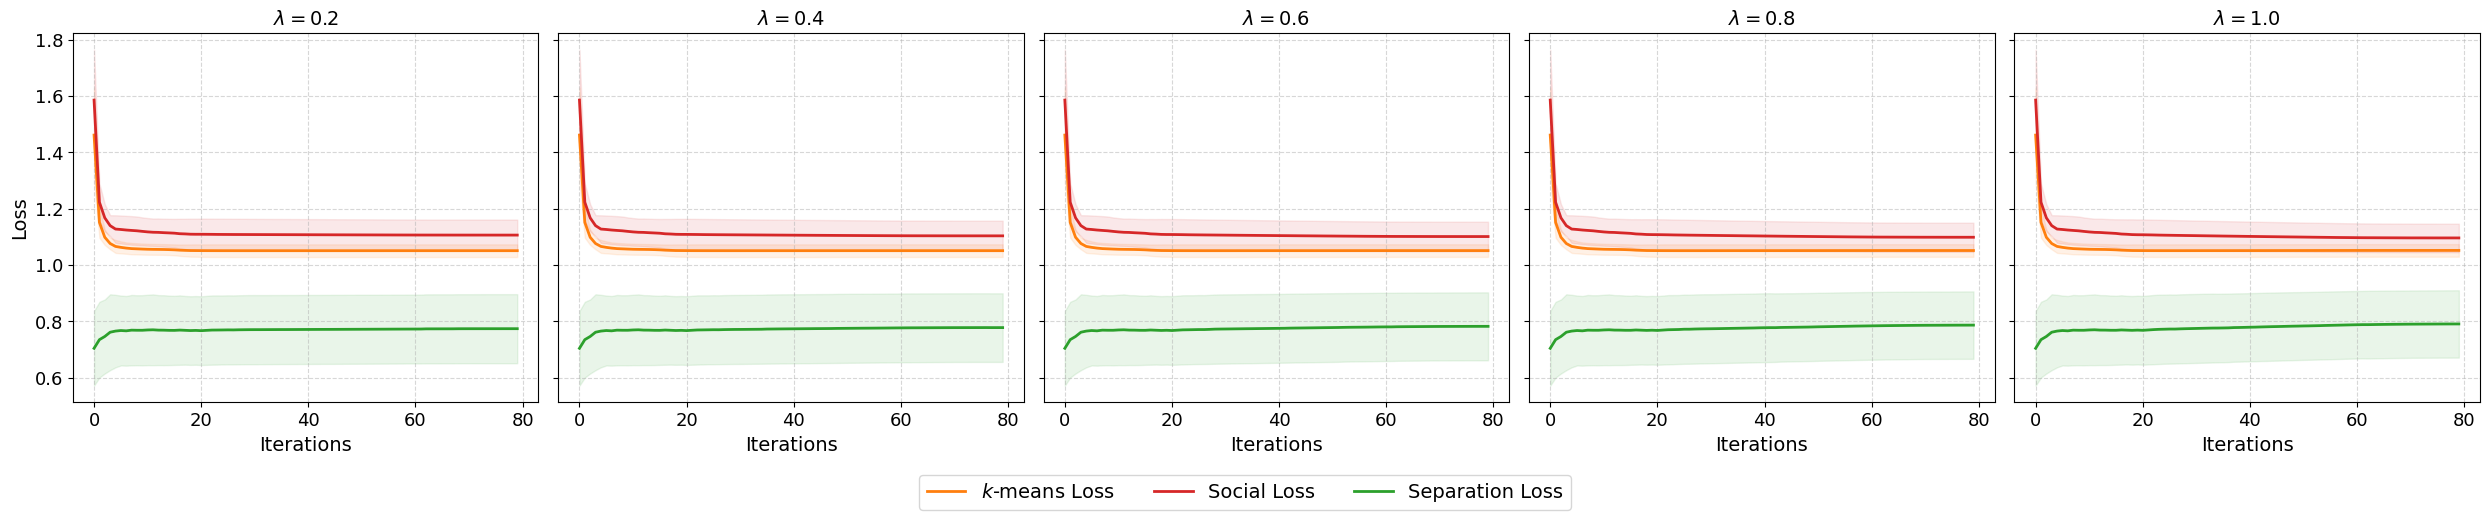

In [ ]:
# ------------------------------------------------
# 4. Example: run for one dataset
# ------------------------------------------------

# Choose one of: "adult", "credit", "bank", "student"
dataset_name = "bank"

df_lam, cfg = run_separation_social_pipeline(
    dataset_name=dataset_name,
    lambda_list=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    seeds=range(10),
    iters=50,
    lr=0.01,
    save_dir=f"./plots/combined_{dataset_name}",
    weight_mode="balanced"
)